# **<font color="purple">Medical Insurance Cost Prediction -- Practice</font>**
### **<font color="purple">Prof. Tiziana Ligorio</font>**
### **<font color="purple">Hunter College of The City University of New York</font>**

---
---

In [1]:
!pip install lightning -q

zsh:1: command not found: pip


In this notebook we bring together techniques from two previous labs.

We apply these tools to the [Medical Insurance Costs dataset](https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv), which contains 1,338 instances described by 6 features. The task is to **predict individual medical insurance charges in USD** — a continuous regression target.

**Key motivation:** The `smoker` × `bmi` interaction is non-linear — smokers with high BMI pay far more than either smokers with low BMI or non-smokers with high BMI. This interaction is exactly what a DNN can capture and a linear model cannot, making this dataset a compelling case for deep learning over ridge regression.

**Why regression gives smooth loss curves:** MSELoss is continuous and has no decision threshold. Unlike binary cross-entropy (where class imbalance can cause jagged validation curves), squared error loss on a standardized target produces smooth, monotonically decreasing training curves — a visual signature of stable regression training.

We will follow the same five-step supervised learning workflow:
1. [Load and explore the data](#exploration)
2. [Partition the data into Training and Test set](#partition)
3. [Data Preprocessing](#preprocessing)
4. [Select and Train the Model](#model)
5. [Evaluate the Model](#evaluate)

In [2]:
# import the packages we will use
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import sklearn

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

import lightning as L
from lightning.pytorch.callbacks import EarlyStopping

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from scipy import stats

In [3]:
# set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)
L.seed_everything(42, workers=True)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Seed set to 42


Using device: cpu


## The Dataset

The [Medical Insurance Costs dataset](https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv) contains 1,338 health insurance records from the United States. Each row represents one primary beneficiary.

| Column | Type | Description |
|---|---|---|
| `age` | numeric | Age of the primary beneficiary (years) |
| `sex` | categorical (female/male) | Biological sex |
| `bmi` | numeric | Body mass index (kg/m²); healthy range 18.5–24.9 |
| `children` | numeric (integer) | Number of dependents covered |
| `smoker` | categorical (yes/no) | Tobacco use |
| `region` | categorical (northeast/northwest/southeast/southwest) | US residential region |
| `charges` | numeric **(target)** | Individual medical costs billed by insurance (USD) |

In [4]:
url = 'https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv'
insurance = pd.read_csv(url)
insurance.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


<a id="exploration"></a>
# Explore the Data
---

In [5]:
insurance.shape

(1338, 7)

In [6]:
insurance.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


In [7]:
insurance.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

No missing values — one less thing to worry about during preprocessing.

In [8]:
insurance.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


**Note:** `charges` ranges from approximately \$1,100 to \$63,800, with a mean around \$13,270. The large standard deviation — roughly equal to the mean — suggests strong subgroup structure rather than random variation. This hints that one or more categorical features (spoiler: `smoker`) drive most of the variance in insurance costs.

The numeric features are on very different scales: `age` (18–64), `bmi` (15–53), `children` (0–5). Standardization will be essential before feeding these into the network.

### Target Distribution

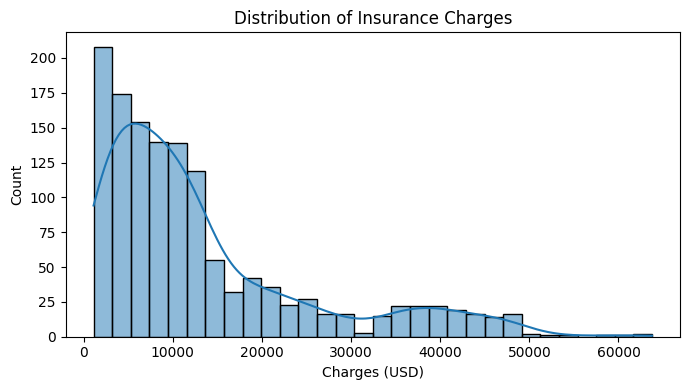

In [9]:
plt.figure(figsize=(7, 4))
sns.histplot(insurance['charges'], kde=True)
plt.title('Distribution of Insurance Charges')
plt.xlabel('Charges (USD)')
plt.tight_layout()
plt.show()

The target is **right-skewed**. Two visible humps suggest two subpopulations — smokers vs non-smokers. Most people pay under \$20K; a tail extends to \$63K.

This confirms `charges` is not Gaussian — but `MSELoss` does **not** require Gaussian targets; it simply minimizes squared error regardless of distribution shape. The right-skewed distribution is handled by standardizing the target before training (see Preprocessing step).

### The Smoker Effect

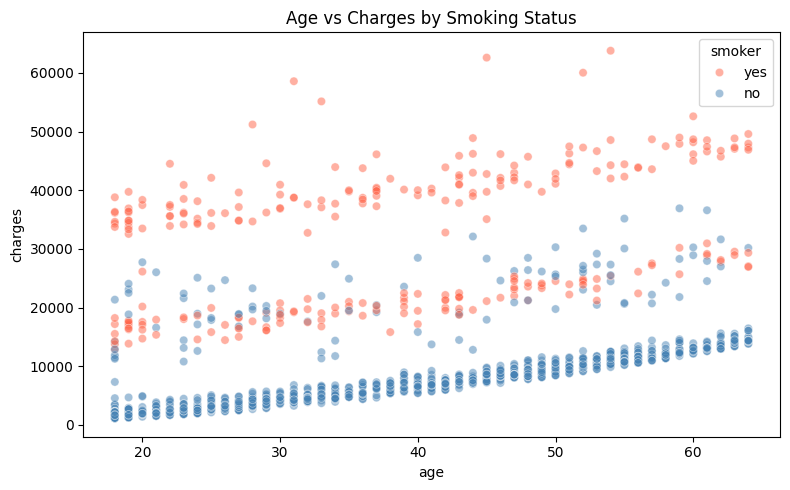

In [10]:
plt.figure(figsize=(8, 5))
sns.scatterplot(
    x='age', y='charges',
    hue='smoker',
    palette={'no': 'steelblue', 'yes': 'tomato'},
    alpha=0.5,
    data=insurance
)
plt.title('Age vs Charges by Smoking Status')
plt.tight_layout()
plt.show()

Two clear bands: **non-smokers** (blue, lower) and **smokers** (red, higher). Within each band, charges increase with age. The gap between bands represents the cost of smoking — roughly \$15K–\$20K extra regardless of age. There is no overlap between the bands.

A linear model could learn this with a dummy variable for `smoker`. But note the smoker band is wider at high ages — suggesting an interaction that a linear model cannot capture fully.

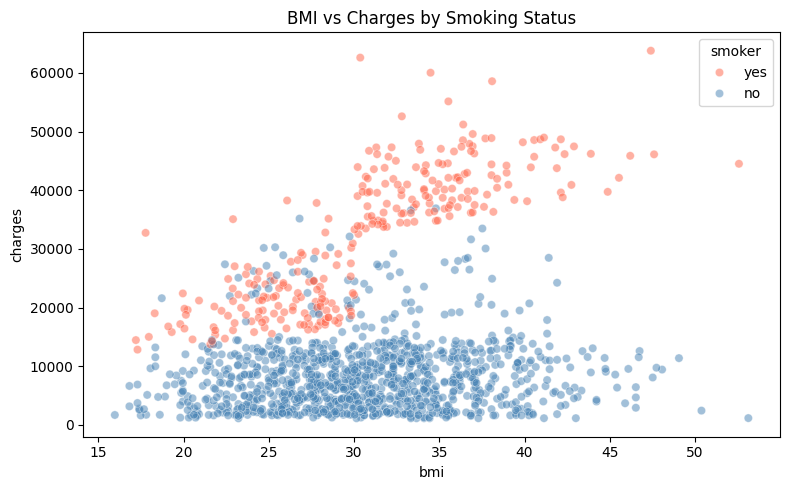

In [11]:
plt.figure(figsize=(8, 5))
sns.scatterplot(
    x='bmi', y='charges',
    hue='smoker',
    palette={'no': 'steelblue', 'yes': 'tomato'},
    alpha=0.5,
    data=insurance
)
plt.title('BMI vs Charges by Smoking Status')
plt.tight_layout()
plt.show()

For **non-smokers** (blue), charges are roughly flat across BMI — BMI has little effect on its own. For **smokers** (red), there is a clear split around BMI ≈ 30 (the obesity threshold): smokers with BMI ≥ 30 pay dramatically more than smokers with BMI < 30.

This is a **pure interaction effect**: neither smoking alone nor high BMI alone produces the spike — it requires *both*. This non-linear interaction is exactly what a DNN can capture and a linear model cannot. It is the key motivation for choosing a DNN over ridge regression for this dataset.

### Categorical Features

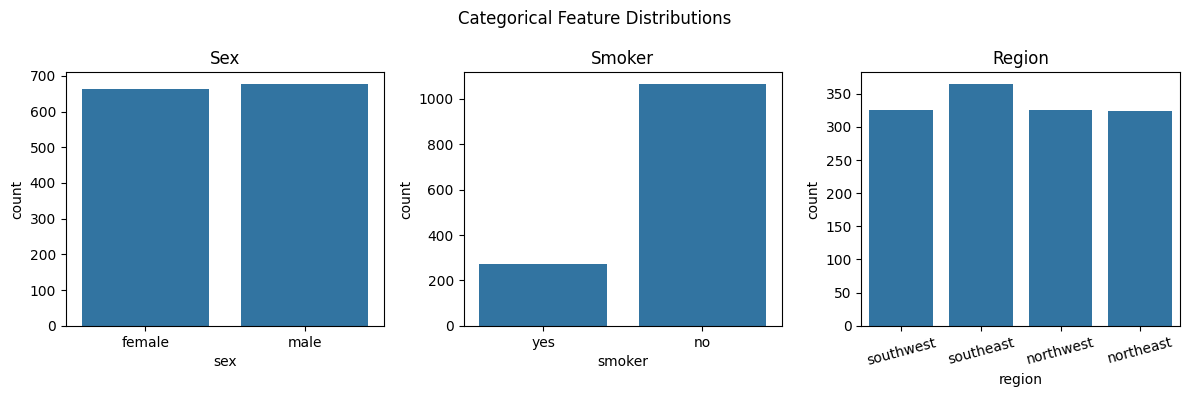

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
fig.suptitle('Categorical Feature Distributions')

sns.countplot(x='sex', data=insurance, ax=axes[0])
axes[0].set_title('Sex')

sns.countplot(x='smoker', data=insurance, ax=axes[1])
axes[1].set_title('Smoker')

sns.countplot(x='region', data=insurance, ax=axes[2])
axes[2].set_title('Region')
axes[2].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

Smokers are approximately 20% of the population — a minority, but their outsized effect on charges makes `smoker` the most predictive single feature. The region split is roughly uniform across all four US regions. There are slightly more males than females in the dataset.

### Correlation Analysis

The correlation matrix only captures **linear** relationships between numeric columns. We include `smoker` as a binary-encoded column (`smoker_enc`) so its linear correlation with `charges` is visible — though the true relationship involves the BMI interaction shown above.

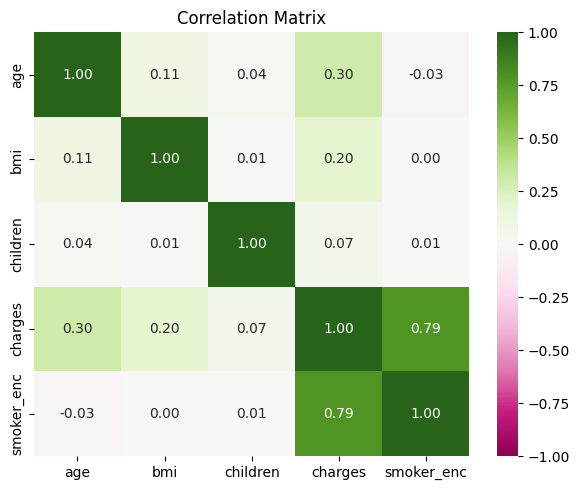

In [13]:
corr_data = insurance[['age', 'bmi', 'children', 'charges']].copy()
corr_data['smoker_enc'] = (insurance['smoker'] == 'yes').astype(int)
plt.figure(figsize=(6, 5))
sns.heatmap(corr_data.corr(), cmap='PiYG', vmin=-1, vmax=1, annot=True, fmt='.2f')
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

`smoker_enc` has the **highest linear correlation** with `charges` (≈ 0.79). `age` is second (≈ 0.30). `bmi` on its own has weak linear correlation (≈ 0.20) — its effect is **conditional on smoking status**, which a correlation coefficient cannot capture.

This is precisely why the DNN is necessary: the important signal in `bmi` is non-linear and interaction-dependent.

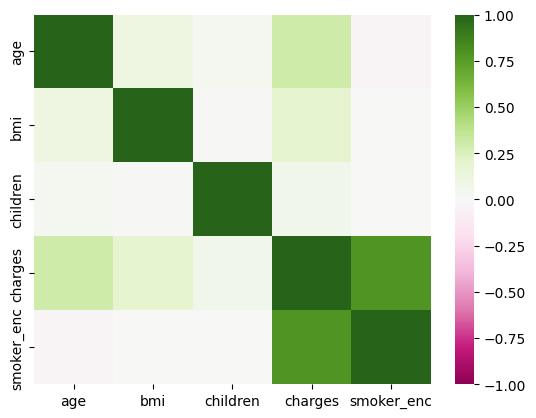

In [14]:
heat_data = insurance.copy()
heat_data['smoker_enc'] = (insurance['smoker'] == 'yes').astype(int)
sns.heatmap(heat_data.corr(numeric_only=True), cmap='PiYG', vmin=-1, vmax=1);

<a id="partition"></a>
# Partition into Training and Test Set
---

We separate the target `y` from the features `X` and set aside 20% for final evaluation.
No stratification is needed — the regression target `charges` is a continuous value, not a class label.

In [15]:
X = insurance.drop('charges', axis=1)
y = insurance['charges'].values  # numpy array

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print('X_train:', X_train.shape, '  X_test:', X_test.shape)

X_train: (1070, 6)   X_test: (268, 6)


<a id="preprocessing"></a>
# Data Preprocessing
---
---

We follow the same preprocessing pipeline from Lab 1:
1. **Impute** missing values with the training median (though we verified there are none)
2. **Standardize** numeric features (Z-score)
3. **One-hot encode** categorical features
4. Concatenate the two parts back together

All transformations are `fit` on the training set **only**; the test set is only `transform`-ed.

**Key addition for regression:** we also standardize the **target** `y`. Training on raw dollar values (range \$1K–\$64K) would produce very large MSE values (in the billions of squared dollars), making it harder for the optimizer to navigate. Standardizing `y` to mean 0 and std 1 keeps the loss in a numerically comfortable range. After training, we inverse-transform predictions back to dollars for interpretable RMSE.

In [16]:
categorical_cols = ['sex', 'smoker', 'region']
numeric_cols = ['age', 'bmi', 'children']

X_train_num = X_train[numeric_cols].copy()
X_test_num  = X_test[numeric_cols].copy()

In [17]:
# impute (no-op here since there are no missing values, but good practice)
imputer = SimpleImputer(strategy='median')
X_train_num = imputer.fit_transform(X_train_num)
X_test_num  = imputer.transform(X_test_num)

print('NaN in train:', np.count_nonzero(np.isnan(X_train_num)))
print('NaN in test: ', np.count_nonzero(np.isnan(X_test_num)))

NaN in train: 0
NaN in test:  0


In [18]:
# z-score standardization — fit on training set only
scaler = StandardScaler()
X_train_num = scaler.fit_transform(X_train_num)
X_test_num  = scaler.transform(X_test_num)
print('Numeric train shape:', X_train_num.shape)

Numeric train shape: (1070, 3)


In [19]:
# one-hot encode categorical features — fit on training set only
cat_encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
X_train_cat = cat_encoder.fit_transform(X_train[categorical_cols])
X_test_cat  = cat_encoder.transform(X_test[categorical_cols])

print('One-hot train shape:', X_train_cat.shape)
print('Total one-hot columns:', X_train_cat.shape[1],
      '(', sum(len(c) for c in cat_encoder.categories_), 'categories )')

One-hot train shape: (1070, 8)
Total one-hot columns: 8 ( 8 categories )


In [20]:
# bring numeric and categorical back together
X_train_processed = np.concatenate((X_train_num, X_train_cat), axis=1)
X_test_processed  = np.concatenate((X_test_num,  X_test_cat),  axis=1)

print('Processed train shape:', X_train_processed.shape)
print('Processed test shape: ', X_test_processed.shape)

Processed train shape: (1070, 11)
Processed test shape:  (268, 11)


In [21]:
# standardize the target — fit on training labels only
y_scaler = StandardScaler()
y_train_scaled = y_scaler.fit_transform(y_train.reshape(-1, 1)).flatten()
y_test_scaled  = y_scaler.transform(y_test.reshape(-1, 1)).flatten()
print(f'y_train mean (scaled): {y_train_scaled.mean():.4f}  std: {y_train_scaled.std():.4f}')

y_train mean (scaled): 0.0000  std: 1.0000


In [22]:
X_train_f, X_valid, y_train_f, y_valid = train_test_split(
    X_train_processed, y_train_scaled, test_size=0.2, random_state=42
)
print('Train:', X_train_f.shape, '  Val:', X_valid.shape)

Train: (856, 11)   Val: (214, 11)


<a id="model"></a>
# Select and Train the Model
---

## Building the model

In [23]:
n_features = X_train_f.shape[1]
print(f'Number of input features: {n_features}')

def build_model():
    """
    Returns a 3-layer fully connected regression network as an nn.Sequential.

    The output layer has a single unit with no activation:
    MSELoss expects a raw scalar prediction, not a probability.
    """
    return nn.Sequential(
        nn.Linear(n_features, 64), nn.ReLU(), 
        nn.Linear(64, 64),         nn.ReLU(), 
        nn.Linear(64, 64),         nn.ReLU(), 
        nn.Linear(64, 1)           # single output — predicted insurance charge (standardized)
    )

Number of input features: 11


In [24]:
class EpochProgressBar(L.Callback):
    """Prints one line per epoch with train and val loss.
    on_train_epoch_end fires after validation, so both metrics are available.
    """
    def on_train_epoch_end(self, trainer, pl_module):
        m     = trainer.callback_metrics
        epoch = trainer.current_epoch + 1
        total = trainer.max_epochs
        print(f'Epoch {epoch}/{total}'
              f'  loss: {m.get("train_loss", float("nan")):.4f}'
              f'  val_loss: {m.get("val_loss", float("nan")):.4f}')

In [25]:
class InsuranceRegressor(L.LightningModule):
    """
    LightningModule for insurance cost regression.

    Encapsulates the model, loss, optimizer, and train/val/test logic.
    The Trainer calls training_step, validation_step, and test_step;
    no manual loop is needed.
    """
    def __init__(self):
        super().__init__()
        self.model     = build_model()
        self.criterion = nn.MSELoss()
        self.history   = {'loss': [], 'val_loss': []}

    def forward(self, x):
        return self.model(x)

    def training_step(self, batch, batch_idx):
        X, y  = batch
        loss  = self.criterion(self(X), y)
        self.log('train_loss', loss, on_epoch=True, on_step=False, prog_bar=True)
        return loss

    def validation_step(self, batch, batch_idx):
        X, y  = batch
        loss  = self.criterion(self(X), y)
        self.log('val_loss', loss, prog_bar=True)

    def test_step(self, batch, batch_idx):
        X, y  = batch
        loss  = self.criterion(self(X), y)
        self.log('test_loss', loss)

    def on_train_epoch_end(self):
        # Fires after validation; both train and val metrics are available
        m = self.trainer.callback_metrics
        self.history['loss'].append(m['train_loss'].item())
        self.history['val_loss'].append(m['val_loss'].item())

    def configure_optimizers(self):
        # Adam adapts the learning rate per parameter — well-suited for
        # mixed feature types (dense numeric + sparse one-hot columns)
        return torch.optim.Adam(self.parameters(), lr=0.001)


# instantiate for architecture inspection (cells below)
reg = InsuranceRegressor()

### Other optimizer options
* SGD — stochastic gradient descent, the fundamental optimizer    
`torch.optim.SGD(self.parameters(), lr=0.01)`

* SGD with momentum — smooths updates by accumulating a velocity vector; often outperforms plain SGD  
`torch.optim.SGD(self.parameters(), lr=0.01, momentum=0.9)`

* Adam — adaptive learning rates per parameter; converges faster than SGD, less sensitive to lr choice; **the most widely used optimizer** — particularly effective when the input mixes dense numeric columns and sparse one-hot columns  
`torch.optim.Adam(self.parameters(), lr=0.001)`

Let's inspect the model architecture with `torchinfo.summary()`, which shows each layer's
output shape and parameter count:

In [26]:
from torchinfo import summary

# input_size = (batch_size, n_features)
summary(reg, input_size=(1, n_features), col_names=['output_size', 'num_params'])

Layer (type:depth-idx)                   Output Shape              Param #
InsuranceRegressor                       [1, 1]                    --
├─Sequential: 1-1                        [1, 1]                    --
│    └─Linear: 2-1                       [1, 64]                   768
│    └─ReLU: 2-2                         [1, 64]                   --
│    └─Linear: 2-3                       [1, 64]                   4,160
│    └─ReLU: 2-4                         [1, 64]                   --
│    └─Linear: 2-5                       [1, 64]                   4,160
│    └─ReLU: 2-6                         [1, 64]                   --
│    └─Linear: 2-7                       [1, 1]                    65
Total params: 9,153
Trainable params: 9,153
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.01
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.04
Estimated Total Size (MB): 0.04

In [27]:
# ── Evaluate helper ───────────────────────────────────────────────────────
def evaluate_regressor(regressor, X_test_t, y_test_scaled, y_scaler):
    """Predict on test set; report RMSE in original dollar units + 95% CI."""
    regressor.eval()
    with torch.no_grad():
        preds_scaled = regressor(X_test_t.to(regressor.device)).cpu().numpy().flatten()

    preds   = y_scaler.inverse_transform(preds_scaled.reshape(-1, 1)).flatten()
    y_true  = y_scaler.inverse_transform(y_test_scaled.reshape(-1, 1)).flatten()

    residuals_sq = (preds - y_true) ** 2
    mse  = residuals_sq.mean()
    rmse = np.sqrt(mse)

    # 95% CI via delta method: Var(RMSE) ≈ Var(MSE) / (4 * MSE)
    n  = len(y_true)
    se = np.sqrt(residuals_sq.var() / n) / (2 * rmse)
    ci = (rmse - 1.96 * se, rmse + 1.96 * se)

    print(f'RMSE: ${rmse:,.0f}')
    print(f'95% CI: [${ci[0]:,.0f}, ${ci[1]:,.0f}]')
    return preds, rmse, ci

In [28]:
def get_loader(X, y, batch_size=32, shuffle=True):
    """Wrap numpy arrays in a PyTorch DataLoader with batch_size=32 (Lightning default)."""
    ds = TensorDataset(
        torch.tensor(X.copy(), dtype=torch.float32),
        torch.tensor(y.copy(), dtype=torch.float32).unsqueeze(1)
    )
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle)

In [29]:
train_loader = get_loader(X_train_f, y_train_f)
val_loader   = get_loader(X_valid, y_valid, shuffle=False)

# Prepare test tensor once — used in the Evaluate section
X_test_t = torch.tensor(X_test_processed.copy(), dtype=torch.float32)

reg = InsuranceRegressor()

# Trainer replaces the manual epoch/batch loop.
#   accelerator="auto"           → GPU if available, CPU otherwise
#   gradient_clip_val=1.0        → clips gradient L2 norm; prevents runaway updates
#   enable_progress_bar=False + EpochProgressBar → one clean line per epoch
trainer = L.Trainer(
    max_epochs=30,
    accelerator='auto',
    enable_model_summary=False,
    callbacks=[EpochProgressBar()],
    enable_progress_bar=False,
    gradient_clip_val=1.0,
    gradient_clip_algorithm='norm'
)

trainer.fit(reg, train_loader, val_loader)

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
/Users/tizianaligorio/dev/deeplearning_notebooks/.venv/lib/python3.12/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/Users/tizianaligorio/dev/deeplearning_notebooks/.venv/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the

Epoch 1/30  loss: 0.8849  val_loss: 0.8137
Epoch 2/30  loss: 0.4236  val_loss: 0.3104
Epoch 3/30  loss: 0.2121  val_loss: 0.2280
Epoch 4/30  loss: 0.1667  val_loss: 0.2112
Epoch 5/30  loss: 0.1606  val_loss: 0.2071
Epoch 6/30  loss: 0.1506  val_loss: 0.2098
Epoch 7/30  loss: 0.1485  val_loss: 0.2037
Epoch 8/30  loss: 0.1425  val_loss: 0.2116
Epoch 9/30  loss: 0.1429  val_loss: 0.1987
Epoch 10/30  loss: 0.1378  val_loss: 0.2021
Epoch 11/30  loss: 0.1385  val_loss: 0.2123
Epoch 12/30  loss: 0.1395  val_loss: 0.2028
Epoch 13/30  loss: 0.1348  val_loss: 0.1968
Epoch 14/30  loss: 0.1293  val_loss: 0.1973
Epoch 15/30  loss: 0.1278  val_loss: 0.2086
Epoch 16/30  loss: 0.1259  val_loss: 0.1994
Epoch 17/30  loss: 0.1241  val_loss: 0.2002
Epoch 18/30  loss: 0.1241  val_loss: 0.1973
Epoch 19/30  loss: 0.1224  val_loss: 0.2003
Epoch 20/30  loss: 0.1187  val_loss: 0.1981
Epoch 21/30  loss: 0.1213  val_loss: 0.2166
Epoch 22/30  loss: 0.1223  val_loss: 0.2052
Epoch 23/30  loss: 0.1157  val_loss: 0.20

`Trainer.fit` stopped: `max_epochs=30` reached.


Epoch 29/30  loss: 0.1091  val_loss: 0.2027
Epoch 30/30  loss: 0.1088  val_loss: 0.2116


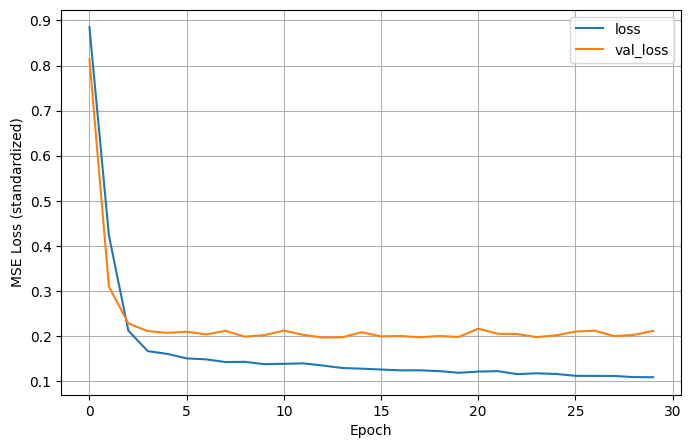

In [30]:
# reg.history is populated by on_train_epoch_end() after each epoch
pd.DataFrame(reg.history).plot(figsize=(8, 5))
plt.grid(True)
plt.ylabel('MSE Loss (standardized)')
plt.xlabel('Epoch')
plt.show()

The training and validation loss both decrease steadily — a signature of stable regression
training with a standardized target and Adam optimizer. Compare `loss` vs `val_loss`:
if the gap widens over time it is a sign of overfitting.

Our choice of 30 epochs is arbitrary. Looking at these curves side by side is a good way
to decide when the model stops generalising.

Keep in mind: the validation set is used to guide training decisions (e.g. when to stop).
It is **not** an unbiased estimate of the model's true performance — that is the test set.

<a name="earlystopping"></a>
## Early Stopping

Let's retrain with a large epoch budget and let **early stopping** decide when to stop.

`EarlyStopping` is a built-in Lightning callback. It monitors a metric (`val_loss`) and
halts training when there is no improvement greater than `min_delta` for `patience`
consecutive epochs. Lightning automatically restores the weights from the best epoch.

**Always re-instantiate `InsuranceRegressor()` to reset the weights before re-training.**

In [31]:
# EarlyStopping parameters:
#   monitor                    → metric to watch
#   mode='min'                 → lower is better
#   patience                   → epochs without improvement before stopping
#   min_delta                  → minimum change that counts as improvement
#   check_on_train_epoch_end=False → check after validation, not after training
early_stop_cb = EarlyStopping(
    monitor='val_loss',
    mode='min',
    patience=15,
    min_delta=0.001,
    check_on_train_epoch_end=False,
    verbose=True
)

reg = InsuranceRegressor()

# max_epochs is a safety ceiling; EarlyStopping will stop training earlier.
trainer = L.Trainer(
    max_epochs=300,
    accelerator='auto',
    enable_model_summary=False,
    callbacks=[EpochProgressBar(), early_stop_cb],
    enable_progress_bar=False,
    gradient_clip_val=1.0,
    gradient_clip_algorithm='norm'
)

trainer.fit(reg, train_loader, val_loader)

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
/Users/tizianaligorio/dev/deeplearning_notebooks/.venv/lib/python3.12/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/Users/tizianaligorio/dev/deeplearning_notebooks/.venv/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the

Epoch 1/300  loss: 0.8772  val_loss: 0.8055
Epoch 2/300  loss: 0.4839  val_loss: 0.3866


Metric val_loss improved by 0.123 >= min_delta = 0.001. New best score: 0.264
Metric val_loss improved by 0.052 >= min_delta = 0.001. New best score: 0.213


Epoch 3/300  loss: 0.2534  val_loss: 0.2641
Epoch 4/300  loss: 0.1762  val_loss: 0.2125


Metric val_loss improved by 0.001 >= min_delta = 0.001. New best score: 0.211


...

Epoch 7/300  loss: 0.1465  val_loss: 0.2143
Epoch 8/300  loss: 0.1420  val_loss: 0.2002
Epoch 9/300  loss: 0.1357  val_loss: 0.2019
Epoch 10/300  loss: 0.1371  val_loss: 0.2018


Metric val_loss improved by 0.002 >= min_delta = 0.001. New best score: 0.198


Epoch 11/300  loss: 0.1308  val_loss: 0.2031
Epoch 12/300  loss: 0.1295  val_loss: 0.1981
Epoch 13/300  loss: 0.1290  val_loss: 0.2002
Epoch 14/300  loss: 0.1261  val_loss: 0.2053
Epoch 15/300  loss: 0.1239  val_loss: 0.1999
Epoch 16/300  loss: 0.1215  val_loss: 0.2048
Epoch 17/300  loss: 0.1202  val_loss: 0.2230
Epoch 18/300  loss: 0.1216  val_loss: 0.2056
Epoch 19/300  loss: 0.1192  val_loss: 0.1981
Epoch 20/300  loss: 0.1160  val_loss: 0.2037
Epoch 21/300  loss: 0.1222  val_loss: 0.2112
Epoch 22/300  loss: 0.1145  val_loss: 0.2079
Epoch 23/300  loss: 0.1135  val_loss: 0.2192
Epoch 24/300  loss: 0.1126  val_loss: 0.2084
Epoch 25/300  loss: 0.1122  val_loss: 0.2220
Epoch 26/300  loss: 0.1125  val_loss: 0.2151


Monitored metric val_loss did not improve in the last 15 records. Best score: 0.198. Signaling Trainer to stop.


Epoch 27/300  loss: 0.1087  val_loss: 0.2138


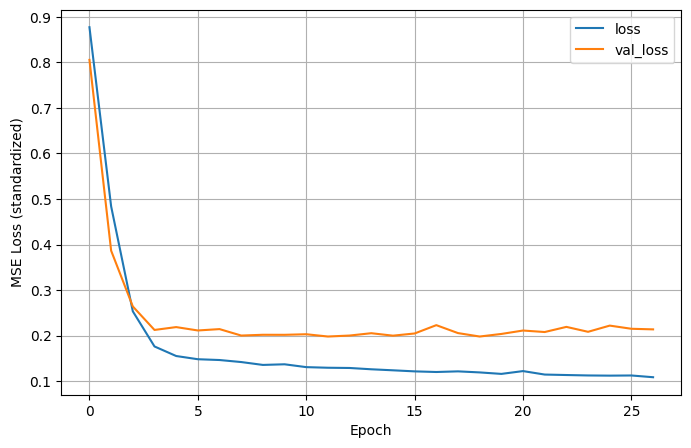

In [32]:
pd.DataFrame(reg.history).plot(figsize=(8, 5))
plt.grid(True)
plt.ylabel('MSE Loss (standardized)')
plt.xlabel('Epoch')
plt.show()

Observing this plot we can see the training and validation curves eventually diverge,
triggering early stopping. The smooth descent is characteristic of regression with a
standardized target — no decision threshold, no class-imbalance spikes.

As we will discuss, very large networks sometimes exhibit **double descent**: the loss
decreases, then rises, then decreases again to a better minimum. Early stopping at the
first rise can prevent finding that second minimum. An alternative is to train for many
epochs while saving **checkpoints** of the best weights.

<a id="evaluate"></a>
# Evaluate the Model
---

We evaluate on the **test set** — data the model has never seen. Predictions are **inverse-transformed** from standardized units back to US dollars.

**RMSE** (Root Mean Squared Error) is the average prediction error in USD — it is interpretable in the same units as `charges`. We supplement the point estimate with a **95% confidence interval** via the delta method to capture uncertainty from the finite test set.

In [33]:
y_hat, rmse, ci = evaluate_regressor(reg, X_test_t, y_test_scaled, y_scaler)

RMSE: $4,630
95% CI: [$3,797, $5,463]


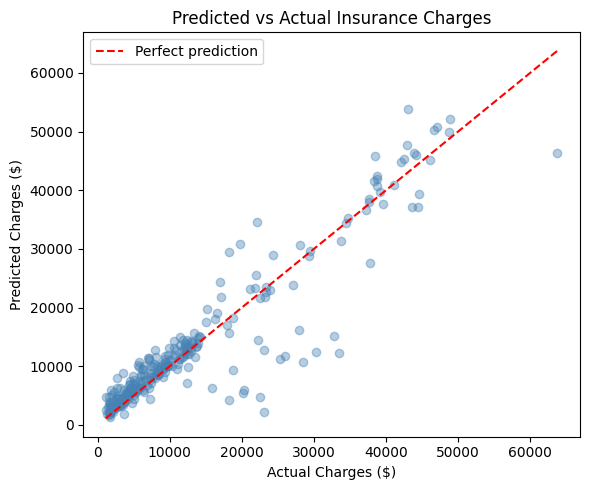

In [34]:
y_true_dollars = y_scaler.inverse_transform(y_test_scaled.reshape(-1, 1)).flatten()
plt.figure(figsize=(6, 5))
plt.scatter(y_true_dollars, y_hat, alpha=0.4, color='steelblue')
plt.plot([y_true_dollars.min(), y_true_dollars.max()],
         [y_true_dollars.min(), y_true_dollars.max()],
         'r--', linewidth=1.5, label='Perfect prediction')
plt.xlabel('Actual Charges ($)')
plt.ylabel('Predicted Charges ($)')
plt.title('Predicted vs Actual Insurance Charges')
plt.legend()
plt.tight_layout()
plt.show()

Points near the red diagonal are accurate predictions. Spread below/above the line shows over/under-prediction.

The smoker subgroup (high-charge cluster, upper right) is typically harder to predict precisely — the smoker×bmi interaction creates a wide spread in charges that our neural network approximates with some error.

### Results Summary

| Metric | Value |
|---|---|
| **RMSE** | $4,630 |
| **95% CI** | [$3,797, $5,463]|



Essentially we can say that 95% of the time our model will predict the charges with an error within the interval [\$3797, \$5463]